In [1]:
!pip install -q shap lightgbm xgboost

# 한글 깨짐 방지를 위한 나눔 폰트 설치 (시각화할 때 한글이 깨지지 않게 해줍니다)
!sudo apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
import seaborn as sns
import pandas as pd

# Seaborn 내장 타이타닉 데이터 로드
raw_data = sns.load_dataset('titanic')

# 데이터 구조 및 결측치 파악을 위한 기본 함수
print("--- Data Shape ---")
print(raw_data.shape)

print("\n--- Data Info ---")
raw_data.info()

print("\n--- Missing Values ---")
print(raw_data.isnull().sum())

--- Data Shape ---
(891, 15)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Missing Values ---
survive

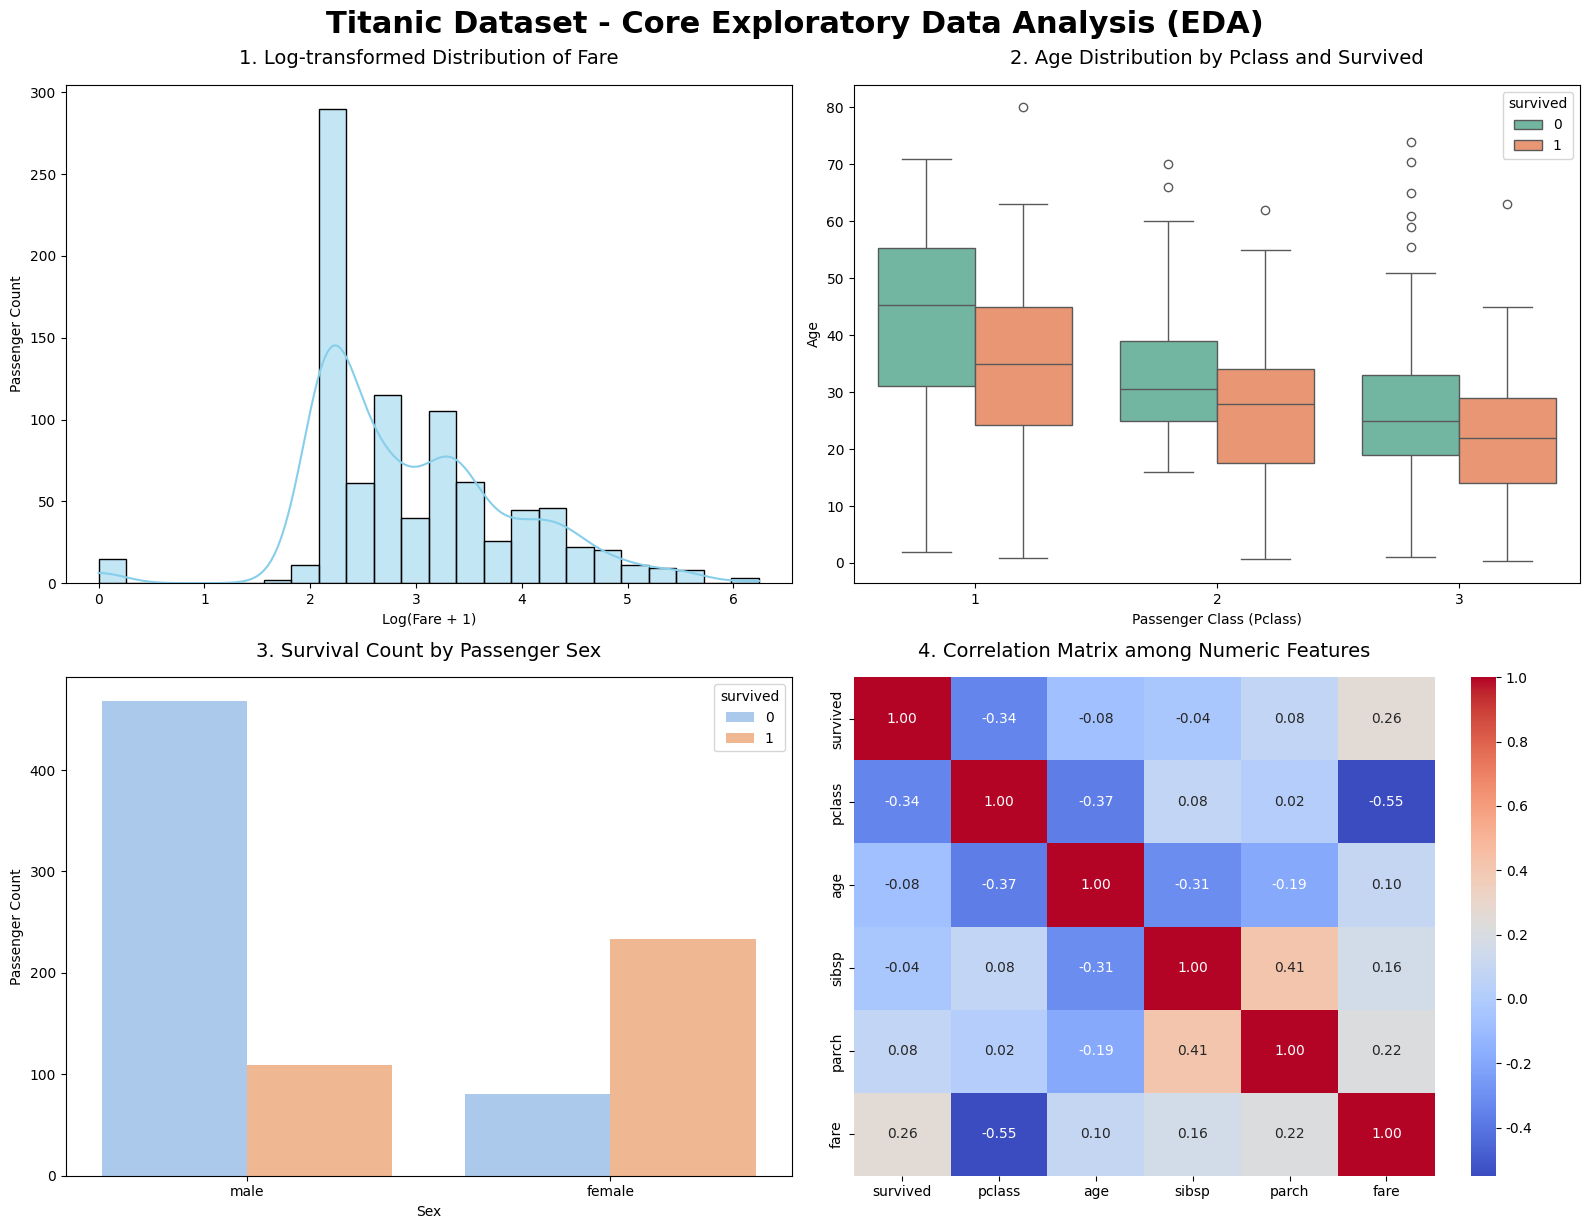

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 기본 스타일 및 폰트 세팅
plt.rc('font', family='sans-serif')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
raw_data = sns.load_dataset('titanic')

# 시각화 틀 설정
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram (Fare Distribution)
# [1번 히스토그램만 로그 변환 적용 버전]
# 기존 fare에 0이 있을 수 있으므로 np.log1p (log(x+1)) 사용
sns.histplot(data=raw_data, x=np.log1p(raw_data['fare']), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Log-transformed Distribution of Fare', fontsize=14, pad=15)
axes[0, 0].set_xlabel('Log(Fare + 1)')
axes[0, 0].set_ylabel('Passenger Count')

# 2. Boxplot (Age Distribution by Pclass & Survived)
sns.boxplot(data=raw_data, x='pclass', y='age', hue='survived', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Age Distribution by Pclass and Survived', fontsize=14, pad=15)
axes[0, 1].set_xlabel('Passenger Class (Pclass)')
axes[0, 1].set_ylabel('Age')

# 3. Countplot (Survival Count by Sex)
sns.countplot(data=raw_data, x='sex', hue='survived', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('3. Survival Count by Passenger Sex', fontsize=14, pad=15)
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Passenger Count')

# 4. Heatmap (Correlation Matrix)
numeric_df = raw_data.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('4. Correlation Matrix among Numeric Features', fontsize=14, pad=15)

# [핵심 수정] 서브플롯 간 격차 정리 후 메인 타이틀을 여백 위(y=0.98)로 강제 배치
plt.tight_layout()
fig.suptitle('Titanic Dataset - Core Exploratory Data Analysis (EDA)', fontsize=22, fontweight='bold', y=1.02)

plt.show()

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. 데이터 로드 및 파생변수 생성
raw_data = sns.load_dataset('titanic')

# [파생 변수 1] FamilySize = 형제자매/배우자(sibsp) + 부모/자녀(parch) + 본인(1)
raw_data['FamilySize'] = raw_data['sibsp'] + raw_data['parch'] + 1

# [파생 변수 2] AgeGroup = 나이대 범주화
raw_data['AgeGroup'] = pd.cut(raw_data['age'], bins=[0, 12, 19, 35, 60, 100], labels=['Child', 'Teenager', 'YoungAdult', 'Adult', 'Elderly'])
raw_data['AgeGroup'] = raw_data['AgeGroup'].astype(object).fillna('Unknown')

# 분석에 사용할 피처와 타겟 정의
num_features = ['age', 'fare', 'FamilySize']
cat_features = ['sex', 'embarked', 'pclass', 'AgeGroup']
X = raw_data[num_features + cat_features].copy()
y = raw_data['survived'].copy()

# 데이터 분할 (Train 80%, Test 20% / 타겟 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 결과를 저장할 리스트
results = []

experiments = {
    'Base': {
        'num_imputer': SimpleImputer(strategy='constant', fill_value=0),
        'cat_imputer': SimpleImputer(strategy='constant', fill_value='missing'),
        'scaler': None,
        'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False), # 최소한의 구동을 위한 인코딩
        'selector': None
    },
    'Exp-1': {
        'num_imputer': SimpleImputer(strategy='mean'),
        'cat_imputer': SimpleImputer(strategy='most_frequent'),
        'scaler': StandardScaler(),
        'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        'selector': None
    },
    'Exp-2': {
        'num_imputer': SimpleImputer(strategy='median'),
        'cat_imputer': SimpleImputer(strategy='most_frequent'),
        'scaler': MinMaxScaler(),
        'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        'selector': SelectKBest(score_func=f_classif, k=5) # 상위 5개 변수 선택
    },
    'Exp-3': {
        'num_imputer': SimpleImputer(strategy='most_frequent'),
        'cat_imputer': SimpleImputer(strategy='most_frequent'),
        'scaler': RobustScaler(),
        'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        'selector': SelectKBest(score_func=f_classif, k=5)
    }
}

# 모델 2개 정의 (Classification)
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# 실험 루프 수행
for exp_name, config in experiments.items():
    # 수치형 변수 전처리 파이프라인
    num_transformer = Pipeline(steps=[
        ('imputer', config['num_imputer']),
        ('scaler', config['scaler']) if config['scaler'] is not None else ('passthrough', 'passthrough')
    ])

    # 범주형 변수 전처리 파이프라인
    cat_transformer = Pipeline(steps=[
        ('imputer', config['cat_imputer']),
        ('encoder', config['encoder'])
    ])

    # 전처리 결합
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

    for model_name, model in models.items():
        # 파이프라인 단계 구성
        pipe_steps = [('preprocessor', preprocessor)]

        # Feature Selection 적용 여부
        if config['selector'] is not None:
            pipe_steps.append(('selector', config['selector']))

        pipe_steps.append(('classifier', model))

        pipeline = Pipeline(steps=pipe_steps)

        # 모델 학습
        pipeline.fit(X_train, y_train)

        # 예측 및 성능 평가
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        # 결과 기록
        results.append({
            '실험 조합': exp_name,
            '적용 모델': model_name,
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc, 4)
        })

# 결과 테이블 출력
df_results = pd.DataFrame(results)
print("\n" + "="*65 + "\n[ 실험 조합별 최종 성능 비교표 ]\n" + "="*65)
print(df_results.to_string(index=False))


[ 실험 조합별 최종 성능 비교표 ]
실험 조합        적용 모델  Accuracy  F1-Score  ROC-AUC
 Base RandomForest    0.8045    0.7368   0.8486
 Base      XGBoost    0.8268    0.7770   0.8342
Exp-1 RandomForest    0.8101    0.7424   0.8374
Exp-1      XGBoost    0.8045    0.7407   0.8140
Exp-2 RandomForest    0.7654    0.7000   0.8237
Exp-2      XGBoost    0.7654    0.7000   0.8215
Exp-3 RandomForest    0.7654    0.7000   0.8237
Exp-3      XGBoost    0.7654    0.7000   0.8215


In [12]:
from sklearn.model_selection import GridSearchCV

best_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', best_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("="*50)
print("[ GridSearchCV 최적화 결과 ]")
print("="*50)
print(f"최적 하이퍼파라미터: {grid_search.best_params_}")
print(f"최고 검증 F1-Score: {grid_search.best_score_:.4f}")

[ GridSearchCV 최적화 결과 ]
최적 하이퍼파라미터: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
최고 검증 F1-Score: 0.7708
